In [2]:
import pandas as pd
import numpy as np
from io import StringIO
import os
## STEP 1: IMPORT LIBRARIES + CLEAN DATA  + DEFINE FUNCTIONS + CHECK FILES  + EXTRACT BASELINE VALUES

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    """
    Load a data file from the ../data folder.

    Parameters:
        filename (str): name of the file (e.g. "Data_GG.csv")

    Returns:
        lines (list): all lines from the file
    """
    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines


# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)

    # ---------- STEP 2: FIND K-PUSH AND K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- STEP 3: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)

    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')

    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            # Try splitting with tab first
            parts = line.strip().split("\t")

            # If tab split fails → try comma
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]

            # Extract numeric values safely
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            # Keep only first 4 values (qx, qy, qz, qw)
            values = values[:4]

            # Assign values to correct sensor
            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- FIND HEADER ----------
    header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)

    move_data_lines = move_lines[header_idx_move + 1:]

    # ---------- PARSE DATA ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")

        if len(row) < 2:
            row = line.strip().split(",")

        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)

    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.ffill().bfill()

    # ---------- STEP 6: EXTRACT SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- FINAL CHECK ----------
    print(f"\n===== FILE: {filename} =====")

    print("K-Push:\n", df_push.head())

    print("\nWrist (S121577):\n", df_wrist.head())

    print("\nShoulder (S121578):\n", df_shoulder.head())

    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])

    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================

# ---------- SELECT FILE(S) ----------
files = ["Data_Et_D.csv"]  # for single files

# files = ["Data_droite.csv", "Data_GG.csv"]  # for multiple files

# ---------- PROCESS FILE(S) ----------
results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)

    results[file] = {
        "push": df_push,
        "wrist": df_wrist,
        "shoulder": df_shoulder,
        "baseline": baseline
            }


===== FILE: Data_Et_D.csv =====
K-Push:
     time    force
0  0.000  0.96355
1  0.002  0.95785
2  0.004  0.95055
3  0.006  0.97225
4  0.008  0.94885

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000 -0.595032  0.070190 -0.090149  0.795471
1  0.008 -0.595022  0.070223 -0.090152  0.795499
2  0.016 -0.594989  0.070284 -0.090152  0.795526
3  0.024 -0.594987  0.070345 -0.090182  0.795523
4  0.032 -0.594984  0.070436 -0.090212  0.795519

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000  0.016052 -0.673950  0.701599  0.230652
1  0.008  0.015961 -0.673933  0.701644  0.230687
2  0.016  0.015808 -0.673901  0.701672  0.230717
3  0.024  0.015656 -0.673901  0.701673  0.230717
4  0.032  0.015503 -0.673879  0.701681  0.230720

Baseline wrist: [-0.038, -0.686, 0.684, 0.245]
Baseline shoulder: [-0.599, 0.079, -0.087, 0.792]

Shapes: (35390, 2) (8845, 5) (8845, 5)



===== FILE: Data_Et_D.csv =====
Ref angle: 30
Wrist range: -75.81150016808222 → -70.49795164493455
Shoulder range: -179.58304526869057 → 179.34192245515464

===== FILE: Data_Et_D.csv =====

Wrist angles:
    time    angle_x  angle_relative
0  0.000 -73.617651     -103.617651
1  0.008 -73.617318     -103.617318
2  0.016 -73.613676     -103.613676
3  0.024 -73.614479     -103.614479
4  0.032 -73.615727     -103.615727

Shoulder angles:
    time    angle_x  angle_relative
0  0.000 -84.456395     -114.456395
1  0.008 -84.453686     -114.453686
2  0.016 -84.448191     -114.448191
3  0.024 -84.448170     -114.448170
4  0.032 -84.444169     -114.444169

Wrist range: -75.81150016808222 → -70.49795164493455
Shoulder range: -179.58304526869057 → 179.34192245515464


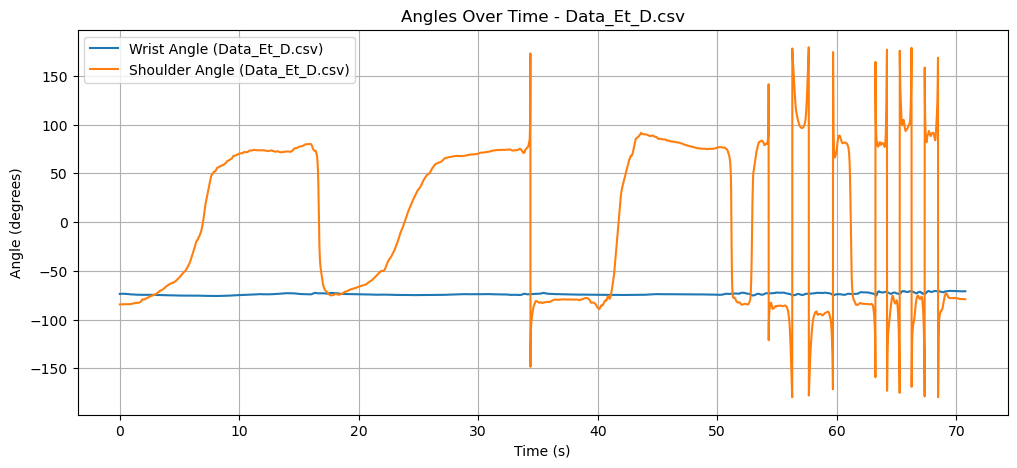

In [10]:
## STEP 3 - MULTI FILES

angle_ref = {
    "Data_Et_D.csv": 30,
    "Data_Et_G.csv": 35,
    "Data_Ch_D.csv": 40
}

angles_results = {}

for file in results:

    df_wrist = results[file]["wrist"]
    df_shoulder = results[file]["shoulder"]

    # 👉 récupère automatiquement le bon angle
    ref = angle_ref[file]

    # ---------- WRIST ----------
    df_wrist_angle = compute_roll_angle(df_wrist)
    df_wrist_angle["angle_relative"] = df_wrist_angle["angle_x"] - ref

    # ---------- SHOULDER ----------
    df_shoulder_angle = compute_roll_angle(df_shoulder)
    df_shoulder_angle["angle_relative"] = df_shoulder_angle["angle_x"] - ref

    # ---------- STORE ----------
    angles_results[file] = {
        "wrist": df_wrist_angle,
        "shoulder": df_shoulder_angle
    }

    print(f"\n===== FILE: {file} =====")
    print("Ref angle:", ref)
    print("Wrist range:", df_wrist_angle["angle_x"].min(), "→", df_wrist_angle["angle_x"].max())
    print("Shoulder range:", df_shoulder_angle["angle_x"].min(), "→", df_shoulder_angle["angle_x"].max())   
    

    ## STEP 3 - CONVERT QUATERNION TO ANGLE (ROLL)

import numpy as np
import pandas as pd

# ==========================================================
# FUNCTION: QUATERNION → ROLL ANGLE
# ==========================================================
def compute_roll_angle(df_quat):
    """
    Convert quaternion to roll angle (X axis) in degrees
    """

    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # Formule roll
    roll_rad = np.arctan2(
        2 * (qw*qx + qy*qz),
        1 - 2 * (qx**2 + qy**2)
    )

    # Conversion degrés
    roll_deg = np.degrees(roll_rad)

    # DataFrame résultat
    df_angle = pd.DataFrame()
    df_angle["time"] = df_quat["time"]
    df_angle["angle_x"] = roll_deg

    return df_angle


# ==========================================================
# PARAMÈTRES (à adapter)
# ==========================================================
# 👉 à remplir avec ton angle de référence réel
angle_ref_wrist = 30   # exemple
angle_ref_shoulder = 30  # exemple


# ==========================================================
# PROCESSING
# ==========================================================
angles_results = {}

for file in results:

    df_wrist = results[file]["wrist"]
    df_shoulder = results[file]["shoulder"]

    # ---------- WRIST ----------
    df_wrist_angle = compute_roll_angle(df_wrist)

    # Angle relatif
    df_wrist_angle["angle_relative"] = df_wrist_angle["angle_x"] - angle_ref_wrist

    # ---------- SHOULDER ----------
    df_shoulder_angle = compute_roll_angle(df_shoulder)

    df_shoulder_angle["angle_relative"] = df_shoulder_angle["angle_x"] - angle_ref_shoulder

    # ---------- STOCKAGE ----------
    angles_results[file] = {
        "wrist": df_wrist_angle,
        "shoulder": df_shoulder_angle
    }

    # ---------- CHECK ----------
    print(f"\n===== FILE: {file} =====")

    print("\nWrist angles:")
    print(df_wrist_angle.head())

    print("\nShoulder angles:")
    print(df_shoulder_angle.head())

    print("\nWrist range:", df_wrist_angle["angle_x"].min(), "→", df_wrist_angle["angle_x"].max())
    print("Shoulder range:", df_shoulder_angle["angle_x"].min(), "→", df_shoulder_angle["angle_x"].max())

    #I want to plot the angles over time to visually check them
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angle["time"], df_wrist_angle["angle_x"], label=f"Wrist Angle ({file})")
    plt.plot(df_shoulder_angle["time"], df_shoulder_angle["angle_x"], label=f"Shoulder Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Angles Over Time - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

